In [4]:
import pandas as pd  
import numpy as np 
 

df =pd.read_csv('c:\\Users\\solan\\Downloads\\archive (10)\\SampleSuperstore.csv')
df.head() 
df.columns = df.columns.str.lower().str.replace(" ","_") 
df.head()

,ship_mode,segment,country,city,state,postal_code,region,category,sub-category,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.isnull().sum()              #data cleaning
df.dropna(inplace = True)

In [6]:
top_products = df.groupby('sub-category')['sales'].sum().sort_values(ascending = False).head(5)      #top selling products
print(top_products)

sub-category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: sales, dtype: float64


In [7]:
region_sales =df.groupby('region')['sales'].sum().sort_values(ascending = False).head(5)            #region wise sales
print(region_sales)

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64


In [8]:
loss_product =df[df['profit'] < 0]                    #loss making product
print(loss_product[['sub-category','profit']])

     sub-category     profit
3          Tables  -383.0310
14     Appliances  -123.8580
15        Binders    -3.8160
23         Chairs    -1.0196
27      Bookcases -1665.0522
...           ...        ...
9920      Binders   -35.8176
9921      Binders    -4.5936
9931    Bookcases   -40.1960
9937       Tables    -1.7772
9962    Bookcases   -67.6704

[1871 rows x 2 columns]


In [9]:
df['profit_margin'] =np.where(df['sales'] > 0,df['profit']/df['sales'],0)      #profit_margin
df

,ship_mode,segment,country,city,state,postal_code,region,category,sub-category,sales,quantity,discount,profit,profit_margin
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,0.1625
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,0.1700
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932,0.0750
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,0.4500


In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns

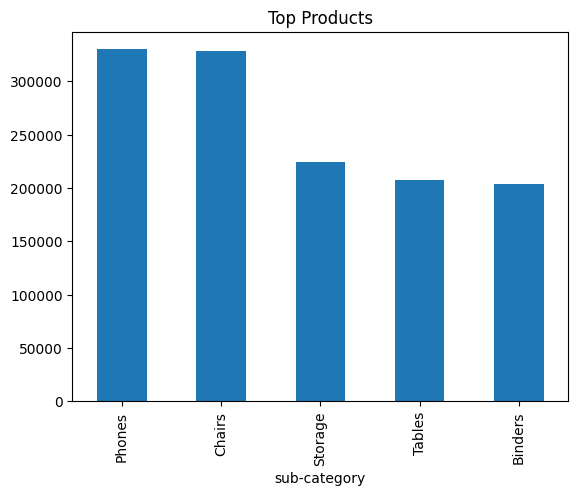

In [11]:
top_products.plot(kind ='bar')
plt.title('Top Products')
plt.show()

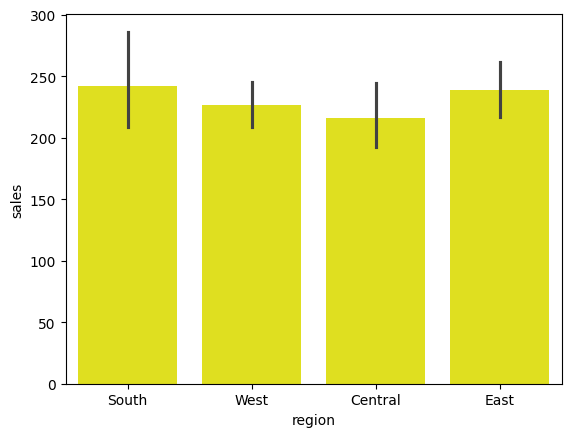

In [12]:
sns.barplot(x=df['region'],y=df['sales'],color ='yellow')
plt.show()

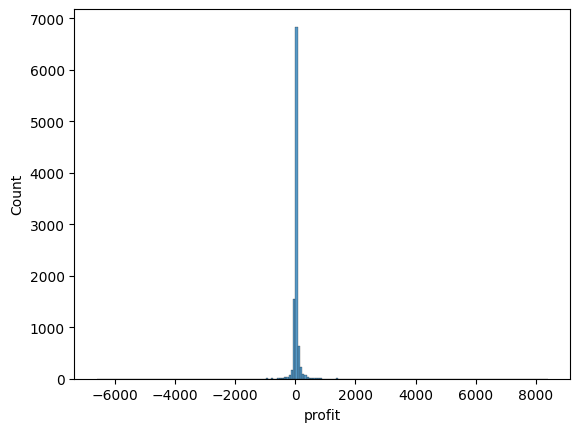

In [13]:
sns.histplot(df['profit'])
plt.show()

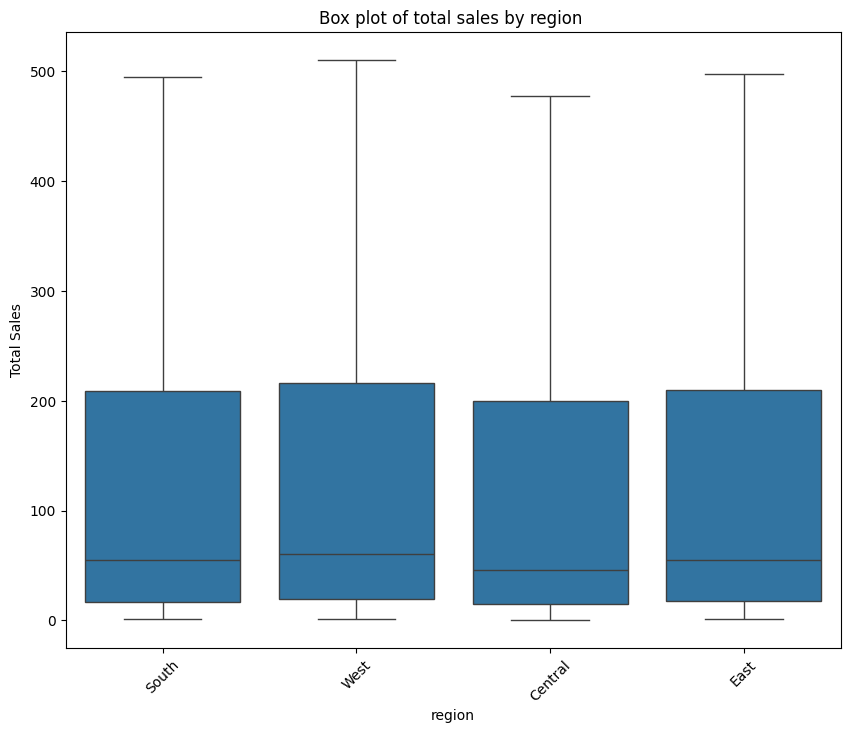

In [14]:
plt.figure(figsize =(10,8))
sns.boxplot(x='region',y='sales',data =df,showfliers = False)
plt.title("Box plot of total sales by region " )
plt.xlabel('region')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.show()

In [15]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import mysql.connector
conn  = mysql.connector.connect(
    host='localhost',
    user='root',
    password='*****',
    database='sales_analysis'
) 
cursor = conn.cursor()

In [17]:
for _, row in df.iterrows():
    cursor.execute("""INSERT INTO sales VALUES(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)""",(
        row['ship_mode'],
        row['segment'],
        row['country'],
        row['city'],
        row['state'],
        int(row['postal_code']),
        row["region"],
        row['category'],
        row['sub-category'],
        float(row['sales']),
        int(row['quantity']),
        float(row['discount']),
        float(row['profit'])
    )) 

conn.commit()
print('data insert')

data insert


C:\Users\solan\AppData\Local\Temp\ipykernel_28316\2397332202.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query,conn)


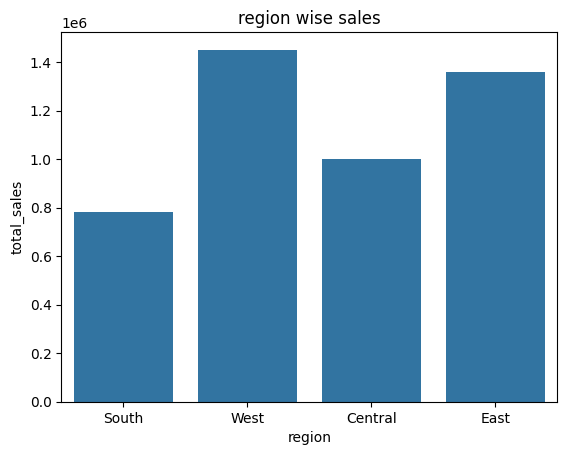

In [18]:
query = """
select region,sum(sales) as total_sales
from sales 
group by region   """ 

df_sql = pd.read_sql(query,conn) 

sns.barplot(x='region',y='total_sales',data=df_sql)
plt.title("region wise sales")
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_28316\4268014894.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 =pd.read_sql(query2,conn)


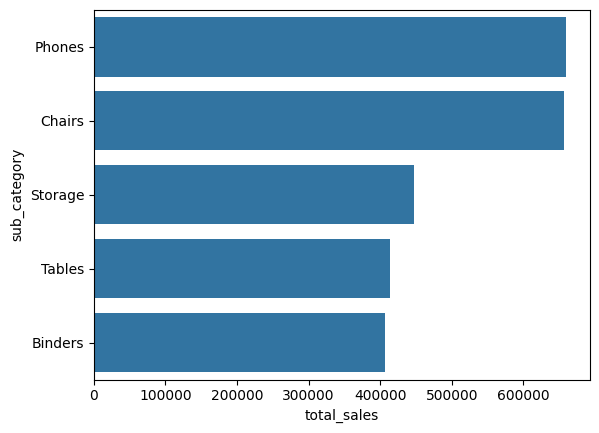

In [19]:
query2= """ 
select sub_category,sum(sales) as total_sales 
from sales 
group by sub_category  
order by total_sales desc limit 5;  """ 

df2 =pd.read_sql(query2,conn) 
sns.barplot(x='total_sales',y='sub_category',data=df2)
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_28316\1898114751.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query3,conn)


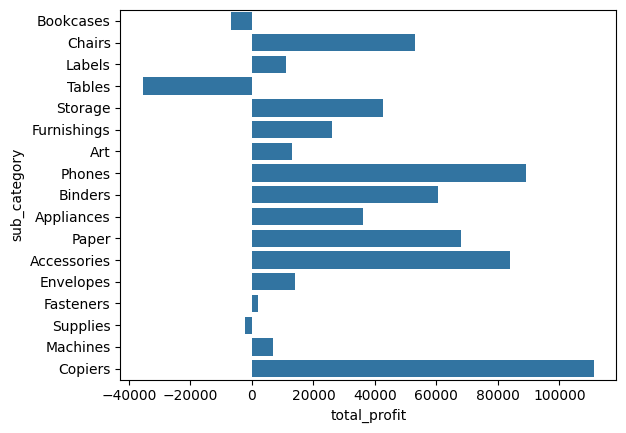

In [20]:
query3 = """ 
select sub_category,sum(profit) AS total_profit
from sales
group by sub_category 
""" 

df3 = pd.read_sql(query3,conn) 

sns.barplot(x='total_profit',y='sub_category',data = df3)
plt.show()

THIS PROJECTS INSIGHTS 

--WEST REGION HAS HIGHEST SALES 
--SOME SUB-CATEGORIES ARE GENERATING LOSS -NEEDX DISCOUNT OPTIMIZATION 